In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


# Task-1

In [2]:
row_size = df.shape[0]
column_size = df.shape[1]
print(f"row size of the data is: {row_size}")
print(f"column size of the data is: {column_size}")

row size of the data is: 200
column size of the data is: 6


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       200 non-null    int64  
 1   city           200 non-null    object 
 2   category       200 non-null    object 
 3   order_value    186 non-null    float64
 4   delivery_days  190 non-null    float64
 5   rating         168 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


In [4]:
order_id_null = df.order_id.isnull().sum()
order_id_null

0

In [5]:
city_null =df.city.isnull().sum()
city_null

0

In [6]:
category_null = df.category.isnull().sum()
category_null

0

In [7]:
order_value_null = df.order_value.isnull().sum()
order_value_null

14

In [8]:
delivery_days_null = df.delivery_days.isnull().sum()
delivery_days_null

10

In [9]:
rating_null = df.rating.isnull().sum()
rating_null

32

In [10]:
print(f"percentage of order_value is {((order_value_null/row_size)*100):.2f} ")
print(f"percentage of delivery_days is {((delivery_days_null/row_size)*100):.2f} ")
print(f"percentage of order_value is {((rating_null/row_size)*100):.2f} ")

percentage of order_value is 7.00 
percentage of delivery_days is 5.00 
percentage of order_value is 16.00 


# Task - 2

In [11]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


### In the order value column the values of Q1,Q2 are 1512 , 3987 respectively.But the max value is 95000 where there is so much difference between Q3 and max value and also there is so much difference between Q1 and min value there are multiple outliers are present 

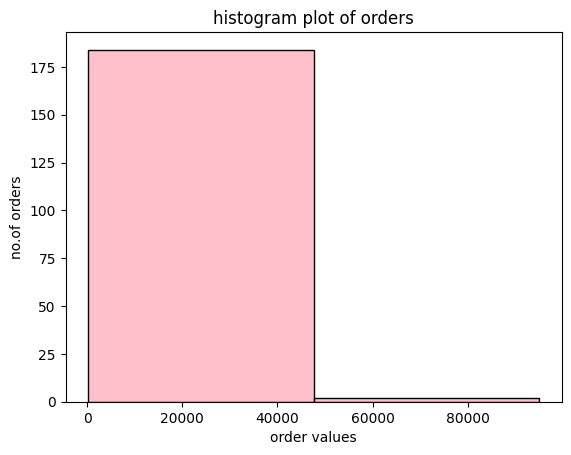

In [36]:
import matplotlib.pyplot as plt
plt.hist(df['order_value'].dropna(),bins=2,color='pink',edgecolor='black')
plt.title("histogram plot of orders")
plt.xlabel("order values")
plt.ylabel("no.of orders")
plt.show()

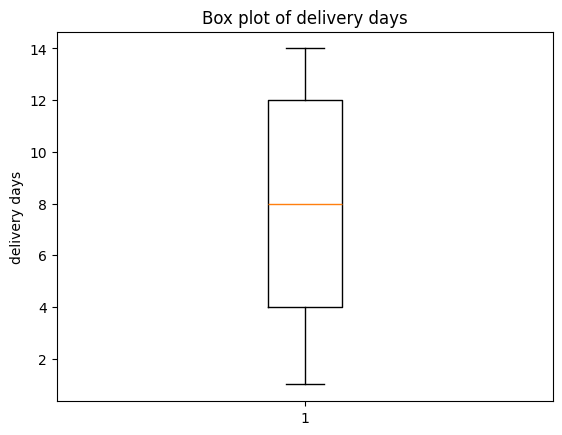

In [37]:
plt.boxplot(df['delivery_days'].dropna())
plt.title("Box plot of delivery days")
plt.ylabel("delivery days")
plt.show()

# Task - 3

In [43]:
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


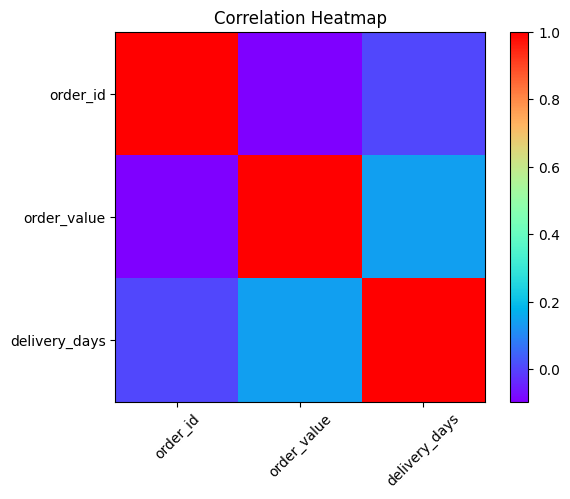

In [62]:
plt.imshow(correlation_matrix, cmap='rainbow')
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
### Delivery days are with negative corelation